Residence time retentate side: 4.267682086855287
Residence time permeate side: 0.008370022877294934


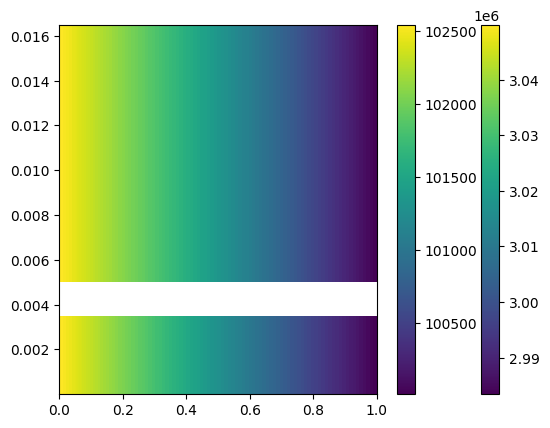

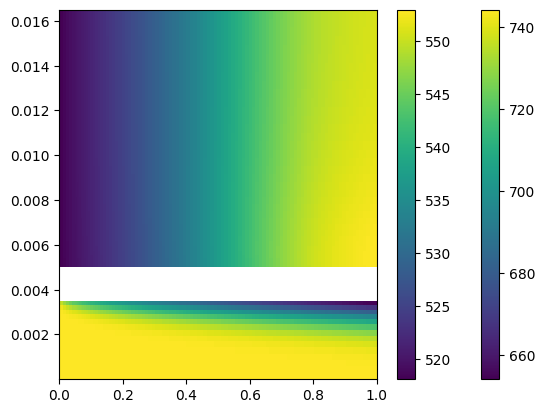

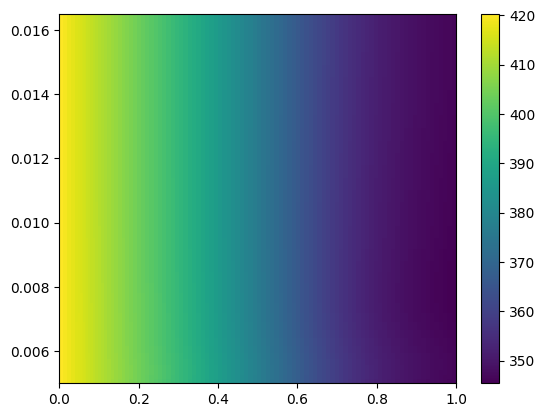

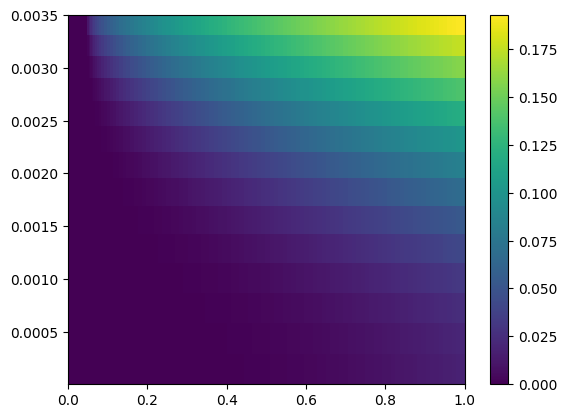

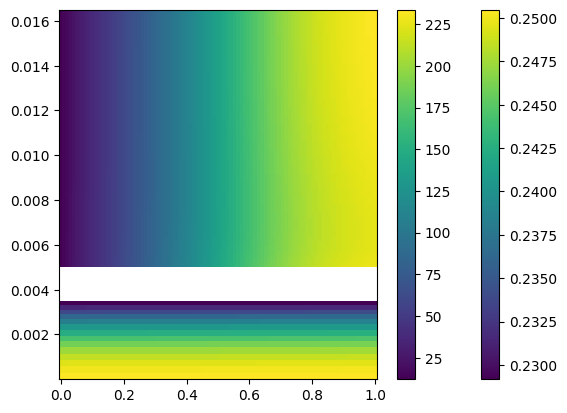

axial flows retentate side: [[0.075      0.025      0.        ]
 [0.06725215 0.02253473 0.00438722]]
axial flows permeate side: [[0.         0.1        0.        ]
 [0.00036818 0.10000543 0.00053256]]
total balance per component: [ 0.00737967  0.00245984 -0.00491978]
elemental H balance: 7.451750142287161e-09
elemental N balance: -9.799173974946868e-08
membrane flow retentate side: [-3.68180211e-04 -5.37773569e-06 -5.32555392e-04]
membrane flow permeate side: [-3.68180211e-04 -5.37773569e-06 -5.32555392e-04]
number of concentration solves: 100
number of pressure solves: 200


In [2]:
from matplotlib import pyplot as plt
import numpy as np
import membrane_reactor
import importlib
importlib.reload(membrane_reactor)
from membrane_reactor import MembraneReactor

#import warnings
#warnings.simplefilter("error")

F = 0.1 # moles per second
reactor = MembraneReactor('input.json', F_ret_in = F, F_perm_in = F, is_counter_current=False)
reactor.info()
    
p = reactor.p
p_vect = p.ravel()
p_perm = p[:, :reactor.num_r_perm]
p_ret = p[:, reactor.num_r_perm:]

reactor.solve()

#plt.plot(reactor.z_c[:], g[:, 0, 0])
#plt.show()

p_min = np.min(p)
p_max = np.max(p)
plt.pcolormesh(reactor.z_c, reactor.r_c_ret, p_ret[:, :].T)
plt.colorbar()
plt.pcolormesh(reactor.z_c, reactor.r_c_perm, p_perm[:, :].T)
plt.colorbar()
plt.show()

#plt.pcolormesh(reactor.z_c, reactor.r_c_ret, reactor.div_u[:, reactor.num_r_perm:].T)
#plt.colorbar()
#plt.pcolormesh(reactor.z_c, reactor.r_c_perm, reactor.div_u[:, :reactor.num_r_perm].T)
#plt.colorbar()
#plt.show()

T_perm = reactor.T[:, :reactor.num_r_perm]
T_ret = reactor.T[:, reactor.num_r_perm:]
plt.pcolormesh(reactor.z_c, reactor.r_c_ret, T_ret[:, :].T)
plt.colorbar()
plt.pcolormesh(reactor.z_c, reactor.r_c_perm, T_perm[:, :].T)
plt.colorbar()
plt.show()

#k_f = reactor.kinetics.k_f
#plt.pcolormesh(reactor.z_c, reactor.r_c_ret, k_f.T)
#plt.colorbar()
#plt.show()

c_perm = reactor.c[:, :reactor.num_r_perm,:]
c_ret = reactor.c[:, reactor.num_r_perm:,:]
plt.pcolormesh(reactor.z_c, reactor.r_c_ret, c_ret[:, :, 0].T)
plt.colorbar()
plt.show()
plt.pcolormesh(reactor.z_c, reactor.r_c_perm, c_perm[:, :, 0].T)
plt.colorbar()
plt.show()

plt.pcolormesh(reactor.z_f, reactor.r_c_ret, reactor.u_ret_ax.T)
plt.colorbar()
plt.pcolormesh(reactor.z_f, reactor.r_c_perm, reactor.u_perm_ax.T)
plt.colorbar()
plt.show()
#plt.plot(reactor.z_f, reactor.u_ret_ax[:, 10], '.')
#plt.show()

flows_ret_ax, flows_ret_mem, flows_perm_ax, flows_perm_mem = reactor.compute_flows()

print(f'axial flows retentate side: {flows_ret_ax}')
print(f'axial flows permeate side: {flows_perm_ax}')
flows_tot = flows_ret_ax[0,:] + flows_perm_ax[0,:] -  flows_ret_ax[-1,:] - flows_perm_ax[-1,:]
print(f'total balance per component: {flows_tot}')
print(f'elemental H balance: {2*flows_tot[0] + 3*flows_tot[2]}')
print(f'elemental N balance: {2*flows_tot[1] + flows_tot[2]}')

print(f'membrane flow retentate side: {flows_ret_mem}')
print(f'membrane flow permeate side: {flows_perm_mem}')

print(f'number of concentration solves: {reactor.cnt_c}')
print(f'number of pressure solves: {reactor.cnt_p}')


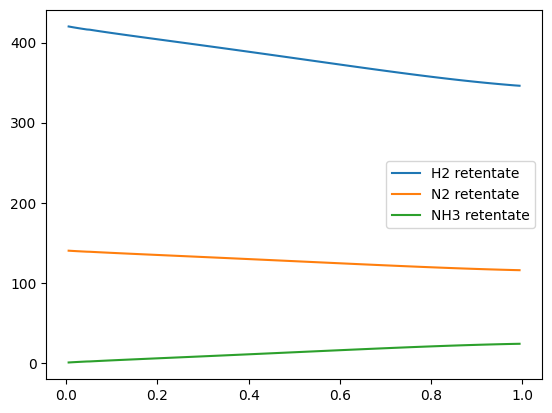

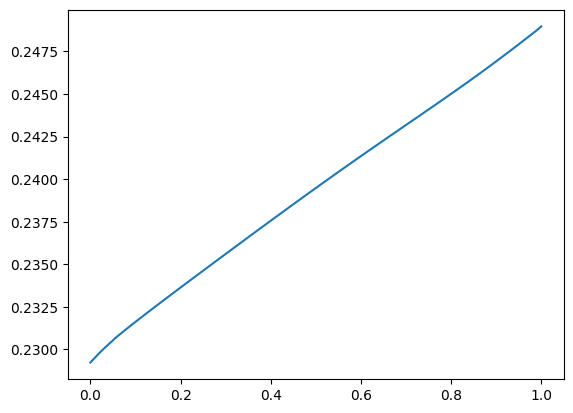

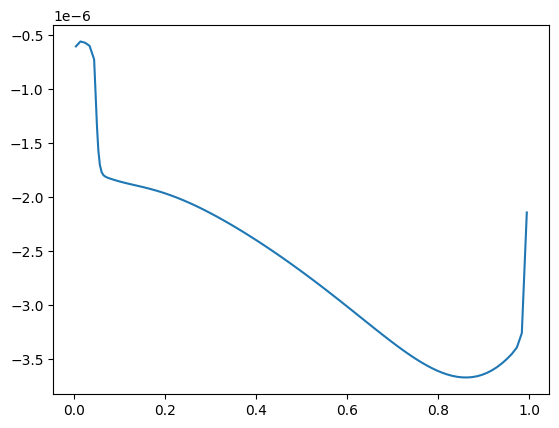

In [4]:
plt.plot(reactor.z_c, c_ret[:, -1, 0], label='H2 retentate')
plt.plot(reactor.z_c, c_ret[:, -1, 1], label='N2 retentate')
plt.plot(reactor.z_c, c_ret[:, -1, 2], label='NH3 retentate')
plt.legend()
plt.show()

#plt.plot(reactor.z_f, reactor.c_ret_ax[:, -5, 0])
plt.plot(reactor.z_f, reactor.u_ret_ax[:, -5])
plt.show()
plt.plot(reactor.z_c, reactor.u_ret_rad[:, -4])
plt.show()
#plt.plot(reactor.z_c, np.sum(c_ret[:, 5, :], axis=1))


In [5]:
reactor.factor_react

1.0

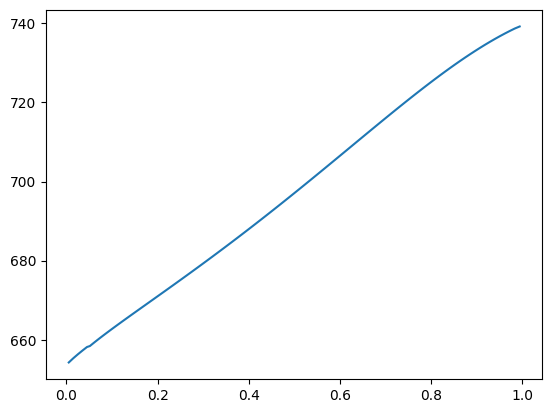

In [6]:
plt.plot(reactor.z_c, T_ret[:, -5])
plt.show()

In [7]:
flows_ret_ax, flows_ret_mem, flows_perm_ax, flows_perm_mem = reactor.compute_flows()

print(f'axial flows retentate side: {flows_ret_ax}')
print(f'axial flows permeate side: {flows_perm_ax}')
flows_tot = flows_ret_ax[0,:] + flows_perm_ax[0,:] -  flows_ret_ax[-1,:] - flows_perm_ax[-1,:]
print(f'total balance per component: {flows_tot}')
print(f'elemental H balance: {2*flows_tot[0] + 3*flows_tot[2]}')
print(f'elemental N balance: {2*flows_tot[1] + flows_tot[2]}')

print(f'membrane flow retentate side: {flows_ret_mem}')
print(f'membrane flow permeate side: {flows_perm_mem}')

axial flows retentate side: [[0.075      0.025      0.        ]
 [0.06685235 0.0224017  0.00440739]]
axial flows permeate side: [[0.         0.1        0.        ]
 [0.0003713  0.10000102 0.00047375]]
total balance per component: [ 0.00777635  0.00259728 -0.00488113]
elemental H balance: 0.000909300340275733
elemental N balance: 0.00031342417276863065
membrane flow retentate side: [-3.69692462e-04 -5.39881488e-06 -4.70978929e-04]
membrane flow permeate side: [-3.69692462e-04 -5.39881488e-06 -4.70978929e-04]


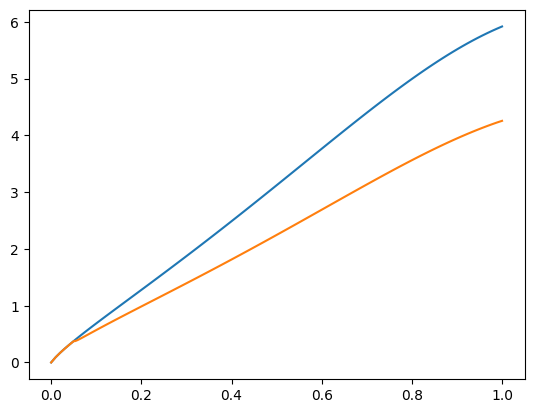

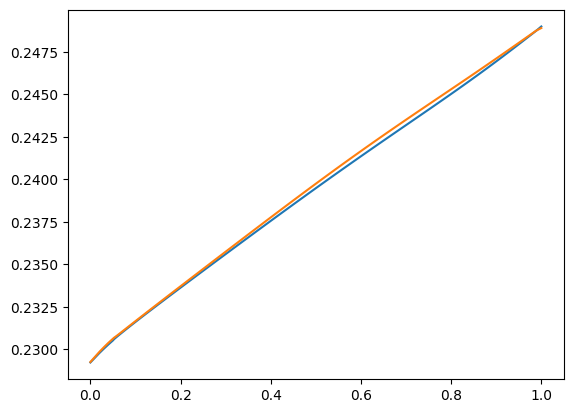

In [8]:
fluxes_ret_ax, fluxes_ret_rad, fluxes_perm_ax, fluxes_perm_rad = reactor.compute_fluxes_conv()

plt.plot(reactor.z_f, fluxes_ret_ax[:, -1, 2])
plt.plot(reactor.z_f, fluxes_ret_ax[:, 0, 2])
plt.show()

plt.plot(reactor.z_f, reactor.u_ret_ax[:, -1])
plt.plot(reactor.z_f, reactor.u_ret_ax[:, 0])
plt.show()


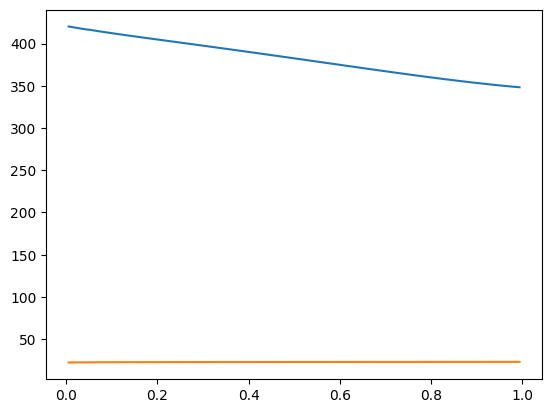

In [9]:
plt.plot(reactor.z_c, reactor.c[:, reactor.num_r_perm,0])
plt.plot(reactor.z_c, np.sum(reactor.c[:, reactor.num_r_perm-1,:], axis = -1))
plt.show()

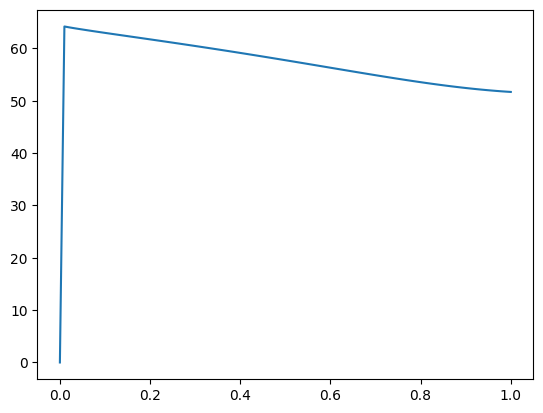

In [10]:
plt.plot(reactor.z_f, np.sum(np.array([[0,2,-1]])*reactor.c_ret_ax[:,-1,:], axis=-1)*reactor.u_ret_ax[:,-1])

In [11]:
from scipy import constants
c_tot = np.sum(membrane_reactor.c,axis=-1)
y = membrane_reactor.c / c_tot[..., np.newaxis]
c_tot_p = membrane_reactor.correlation.molar_density(y, membrane_reactor.T, membrane_reactor.p)

plt.plot(membrane_reactor.z_c, c_tot[:,-1], 'o-r')
plt.plot(membrane_reactor.z_c, c_tot_p[:, -1], '.-g')
plt.show()

#plt.plot(membrane_reactor.z_c, c_tot[:,0], 'o-r')
#plt.plot(membrane_reactor.z_c, c_tot_p[:,0], '.-g')
#plt.show()

p_ig = c_tot_p * constants.R * membrane_reactor.T
plt.plot(membrane_reactor.z_c, p_ig[:,-1], 'o-r')
plt.plot(membrane_reactor.z_c, membrane_reactor.p[:, -1], '.-g')
plt.show()


plt.plot(membrane_reactor.z_f, membrane_reactor.u_ret_ax[:,-1], '-')
plt.show()

grad_p = membrane_reactor.grad_p_ret_ax @ membrane_reactor.p.reshape((-1,1)) + membrane_reactor.grad_bc_p_ret_ax
grad_p = grad_p.reshape((membrane_reactor.num_z+1,-1))
plt.plot(membrane_reactor.z_f[1:], grad_p[1:,-1], '-')
plt.show()

AttributeError: module 'membrane_reactor' has no attribute 'c'